# Part 1: Process the Upper Bound Fed Funds Rate at FOMC Meetings

## Purpose

This notebook converts the daily **Federal Funds Target Range Upper Limit** into an
FOMC-meeting-frequency dataset and labels each meeting as a hike, hold, or cut.

## Notation

| Symbol | Meaning |
|---|---|
| `r_t` | Upper bound of the target federal funds rate observed after FOMC meeting `t` |
| `Δr_t` | Meeting-to-meeting change in the upper bound target rate |
| `decision_t` | Policy action at meeting `t`: `higher`, `same`, or `lower` |

## Output

The notebook exports `processed_fed_meetings.csv`. A published copy is also available at
[`processed_fed_meetings.csv`](https://raw.githubusercontent.com/echochoho1010/forecasting_fed_rate/master/data/processed_fed_meetings.csv), which is the clean meeting-level rate series consumed by Part 2.


In [1]:
import pandas as pd
import numpy as np

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'analysis':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from modeling.notebook_io import data_output_path, resolve_data_source
from modeling.data_refresh import load_fomc_meeting_dates, refresh_fed_rate_sources

# ── Shared helpers ────────────────────────────────────────────────────────────

def minmax_normalize(series):
    """Expanding-window min-max scale a Series to [0, 1] without look-ahead."""
    series = series.astype(float)
    lo = series.expanding(min_periods=1).min()
    hi = series.expanding(min_periods=1).max()
    span = hi - lo
    scaled = pd.Series(np.where(span.eq(0), 0.0, (series - lo) / span),
                       index=series.index, dtype=float)
    return scaled.where(series.notna(), np.nan)

def locf_match(df_src, date_col, val_cols, dates):
    """Last-observation-carry-forward via merge_asof (O(N log N)).

    For each date in *dates* returns the most recent row of df_src
    whose date_col value is <= that date.
    """
    dates_df = pd.DataFrame({'meeting_date': pd.Series(dates).values})
    src = df_src[[date_col] + list(val_cols)].sort_values(date_col)
    result = pd.merge_asof(
        dates_df.sort_values('meeting_date'),
        src,
        left_on='meeting_date',
        right_on=date_col,
        direction='backward',
    )
    if date_col != 'meeting_date':
        result = result.drop(columns=[date_col])
    return result.reset_index(drop=True)

# Refresh local Fed target-rate source files when internet is available.
# Each file is overwritten with the newest complete source copy, not appended.
for refresh_result in refresh_fed_rate_sources(PROJECT_ROOT):
    print(refresh_result.message())

# ── Load the continuous daily Fed Funds rate series ───────────────────────────
file_path = resolve_data_source('Federal Funds Target Range Upper Limit.csv', PROJECT_ROOT)
df = pd.read_csv(file_path)
df['DFEDTARU'] = pd.to_numeric(df['DFEDTARU'], errors='coerce')
df['observation_date'] = pd.to_datetime(df['observation_date'])
df = df.dropna(subset=['DFEDTARU']).sort_values('observation_date').reset_index(drop=True)

df.head()

,observation_date,DFEDTARU
0,2008-12-16,0.25
1,2008-12-17,0.25
2,2008-12-18,0.25
3,2008-12-19,0.25
4,2008-12-20,0.25


### Incorporate FOMC Meeting Dates

We combine the existing historical meeting calendar with the latest FOMC calendar from the Federal Reserve website. The new target rate takes effect on the meeting day itself or the day after. Because the FRED series is continuous, measuring the target rate exactly **1 day after** the meeting will securely yield the post-decision target rate for that meeting. Future scheduled meetings are skipped until the post-meeting target-rate observation is available.

Source: https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm

In [2]:
raw_meetings = load_fomc_meeting_dates(PROJECT_ROOT)

# Ensure date formats are correct and drop any accidental duplicates
df_meetings = pd.DataFrame({'meeting_date': pd.to_datetime(raw_meetings)})
df_meetings = df_meetings.drop_duplicates().sort_values('meeting_date').reset_index(drop=True)

# The decision establishes the target rate that holds the day after the meeting
df_meetings['post_meeting_date'] = df_meetings['meeting_date'] + pd.Timedelta(days=1)

# Merge with the continuous target rate dataframe
df_decisions = pd.merge(
    df_meetings,
    df[['observation_date', 'DFEDTARU']],
    left_on='post_meeting_date',
    right_on='observation_date',
    how='left'
)

# Clean up columns and keep only completed meetings with available target-rate data.
# Scheduled future meetings stay in the calendar source, but are not exported until
# FRED has the post-meeting target rate.
df_decisions = df_decisions[['meeting_date', 'DFEDTARU']].rename(columns={'DFEDTARU': 'target_rate'})
unmatched_meetings = df_decisions[df_decisions['target_rate'].isna()]
df_decisions = df_decisions.dropna(subset=['target_rate']).reset_index(drop=True)

print(f"Loaded {len(raw_meetings)} unique FOMC calendar dates")
print("Total meetings matched to rates:", len(df_decisions))
if not unmatched_meetings.empty:
    next_unmatched = unmatched_meetings['meeting_date'].min().date()
    print(f"Skipped {len(unmatched_meetings)} meetings without target-rate data yet; next skipped date: {next_unmatched}")
df_decisions.head()

Total meetings matched to rates: 140


,meeting_date,target_rate
0,2009-01-28,0.25
1,2009-03-18,0.25
2,2009-04-29,0.25
3,2009-06-24,0.25
4,2009-08-12,0.25


### Determine FOMC Action Labels (`higher`, `same`, `lower`)

Now we calculate the difference between the target rate produced by the *current* meeting and the target rate maintained from the *previous* meeting.

In [3]:
def get_action_label(diff_val):
    if pd.isna(diff_val):
        return None
    elif diff_val > 0:
        return 'higher'
    elif diff_val < 0:
        return 'lower'
    else:
        return 'same'

# Calculate diff from the immediately preceding meeting
df_decisions['previous_rate'] = df_decisions['target_rate'].shift(1)
df_decisions['rate_change'] = df_decisions['target_rate'] - df_decisions['previous_rate']
df_decisions['decision'] = df_decisions['rate_change'].apply(get_action_label)

display(df_decisions.head(15))

,meeting_date,target_rate,previous_rate,rate_change,decision
0,2009-01-28,0.25,NaN,NaN,None
1,2009-03-18,0.25,0.25,0.0,same
2,2009-04-29,0.25,0.25,0.0,same
3,2009-06-24,0.25,0.25,0.0,same
4,2009-08-12,0.25,0.25,0.0,same
5,2009-09-23,0.25,0.25,0.0,same
6,2009-11-04,0.25,0.25,0.0,same
7,2009-12-16,0.25,0.25,0.0,same
8,2010-01-27,0.25,0.25,0.0,same
9,2010-03-16,0.25,0.25,0.0,same


### Descriptive Statistics – Federal Funds Rate

Before visualizing, we summarize the distribution and key properties of the target rate and meeting-level decisions.

Matplotlib is building the font cache; this may take a moment.


  FEDERAL FUNDS RATE  –  DESCRIPTIVE STATISTICS
  Date range   : 2009-01-28  →  2026-01-28
  Total meetings: 140

── Target Rate (%) ──────────────────────────────────


,count,mean,std,min,25%,50%,75%,max
target_rate,140.0,1.5036,1.7928,0.25,0.25,0.25,2.25,5.5



── Decision Distribution ────────────────────────────


,count,pct (%)
decision,,
same,108,77.7
higher,20,14.4
lower,11,7.9



── Rate-Change Episodes ─────────────────────────────


,Date,New Rate (%),Change (pp),Decision
0,2015-12-16,0.50,0.25,higher
1,2016-12-14,0.75,0.25,higher
2,2017-03-15,1.00,0.25,higher
3,2017-06-14,1.25,0.25,higher
4,2017-12-13,1.50,0.25,higher
5,2018-03-21,1.75,0.25,higher
6,2018-06-13,2.00,0.25,higher
7,2018-09-26,2.25,0.25,higher
8,2018-12-19,2.50,0.25,higher
9,2019-07-31,2.25,-0.25,lower



  Avg hike size : +0.375 pp
  Avg cut size  :  -0.364 pp



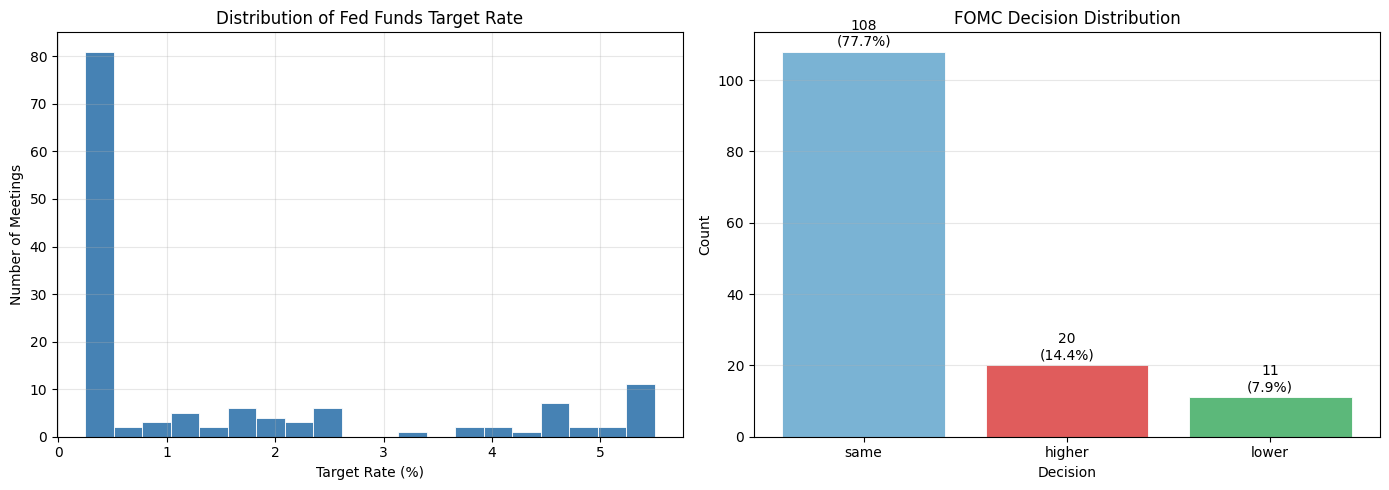

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Coverage ──────────────────────────────────────────────────────────────
print("=" * 55)
print("  FEDERAL FUNDS RATE  –  DESCRIPTIVE STATISTICS")
print("=" * 55)
print(f"  Date range   : {df_decisions['meeting_date'].min().date()}  →  {df_decisions['meeting_date'].max().date()}")
print(f"  Total meetings: {len(df_decisions)}")
print()

# ── 2. Core summary stats on target_rate ────────────────────────────────────
print("── Target Rate (%) ──────────────────────────────────")
display(df_decisions[['target_rate']].describe().T.round(4))
print()

# ── 3. Decision label distribution ──────────────────────────────────────────
decision_counts = df_decisions['decision'].value_counts()
decision_pct    = (decision_counts / decision_counts.sum() * 100).round(1)
decision_summary = pd.DataFrame({'count': decision_counts, 'pct (%)': decision_pct})
print("── Decision Distribution ────────────────────────────")
display(decision_summary)
print()

# ── 4. Rate-change statistics (hikes & cuts only) ────────────────────────────
changes = df_decisions[df_decisions['decision'].isin(['higher', 'lower'])].copy()
print("── Rate-Change Episodes ─────────────────────────────")
display(changes[['meeting_date', 'target_rate', 'rate_change', 'decision']]
        .rename(columns={'meeting_date': 'Date', 'target_rate': 'New Rate (%)',
                         'rate_change': 'Change (pp)', 'decision': 'Decision'})
        .reset_index(drop=True))
print()
print(f"  Avg hike size : +{changes[changes['decision']=='higher']['rate_change'].mean():.3f} pp")
print(f"  Avg cut size  :  {changes[changes['decision']=='lower']['rate_change'].mean():.3f} pp")
print()

# ── 5. Histogram of target rate + decision bar chart (side by side) ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of target rate levels
axes[0].hist(df_decisions['target_rate'].dropna(), bins=20,
             color='steelblue', edgecolor='white', linewidth=0.6)
axes[0].set_title('Distribution of Fed Funds Target Rate')
axes[0].set_xlabel('Target Rate (%)')
axes[0].set_ylabel('Number of Meetings')
axes[0].grid(True, alpha=0.3)

# Bar chart of decision counts
colors = {'higher': '#e05c5c', 'same': '#7ab3d4', 'lower': '#5cb87a'}
bars = axes[1].bar(decision_counts.index,
                   decision_counts.values,
                   color=[colors.get(d, 'gray') for d in decision_counts.index],
                   edgecolor='white', linewidth=0.6)
for bar, (label, count) in zip(bars, decision_counts.items()):
    pct = decision_pct[label]
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.8,
                 f'{count}\n({pct}%)', ha='center', va='bottom', fontsize=10)
axes[1].set_title('FOMC Decision Distribution')
axes[1].set_xlabel('Decision')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Visualize Federal Funds Rate
Let's plot the target rate over time.

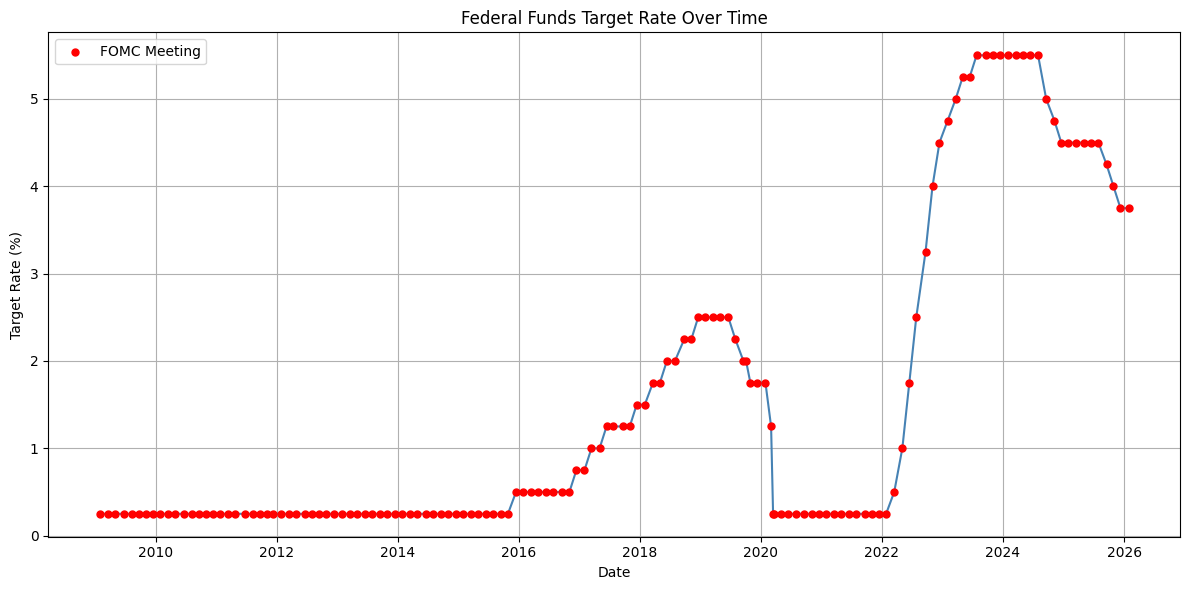

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(x='meeting_date', y='target_rate', data=df_decisions, ax=ax, color='steelblue', linewidth=1.5)
ax.scatter(df_decisions['meeting_date'], df_decisions['target_rate'],
           color='red', s=25, zorder=5, label='FOMC Meeting')
ax.set_title('Federal Funds Target Rate Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Target Rate (%)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### Explore Rate Policy Distribution

Let's see an overview of what the Federal Reserve actually did across these meetings.

In [6]:
print("Overall Rate Changes at Meetings (Distribution):")
display(df_decisions['decision'].value_counts())

print("\nSample of Meetings where rates CHANGED:")
display(df_decisions[df_decisions['decision'].isin(['higher', 'lower'])].head(10))

Overall Rate Changes at Meetings (Distribution):


decision
same      108
higher     20
lower      11
Name: count, dtype: int64


Sample of Meetings where rates CHANGED:


,meeting_date,target_rate,previous_rate,rate_change,decision
55,2015-12-16,0.50,0.25,0.25,higher
63,2016-12-14,0.75,0.50,0.25,higher
65,2017-03-15,1.00,0.75,0.25,higher
67,2017-06-14,1.25,1.00,0.25,higher
71,2017-12-13,1.50,1.25,0.25,higher
73,2018-03-21,1.75,1.50,0.25,higher
75,2018-06-13,2.00,1.75,0.25,higher
77,2018-09-26,2.25,2.00,0.25,higher
79,2018-12-19,2.50,2.25,0.25,higher
84,2019-07-31,2.25,2.50,-0.25,lower


### Export Processed Meeting DataFrame

We add a min-max normalized target rate column (used for overlay charts in Part 2), then export the clean per-meeting DataFrame to CSV. Part 2 will load this file as its starting point.

In [7]:
# Build df_merged: df_decisions + normalized target rate (used for overlay charts in Part 2)
df_merged = df_decisions[['meeting_date', 'target_rate', 'decision']].copy()
df_merged['target_rate_normalized'] = minmax_normalize(df_merged['target_rate'])

# Export for Part 2
out_path = data_output_path('processed_fed_meetings.csv', PROJECT_ROOT)
df_merged.to_csv(out_path, index=False)

print(f"Exported {len(df_merged)} rows → {out_path}")
print(f"Columns: {list(df_merged.columns)}")
display(df_merged.tail())

Exported 140 rows → /Users/echohuang/Documents/forecasting_fed_rate/data/processed_fed_meetings.csv
Columns: ['meeting_date', 'target_rate', 'decision', 'target_rate_normalized']


,meeting_date,target_rate,decision,target_rate_normalized
135,2025-07-30,4.50,same,0.809524
136,2025-09-17,4.25,lower,0.761905
137,2025-10-29,4.00,lower,0.714286
138,2025-12-10,3.75,lower,0.666667
139,2026-01-28,3.75,same,0.666667
